In [1]:
import json

candidates = []

with open("F:\\autorecruit-\\data_forensic _files\\candidates.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        candidates.append(json.loads(line))

In [2]:
import pandas as pd
skills_rows = []

for c in candidates:

    cid = c["candidate_id"]

    for skill in c["skills"]:

        skills_rows.append({
            "candidate_id": cid,
            "skill": skill["name"],
            "proficiency": skill["proficiency"],
            "duration_months": skill["duration_months"],
            "endorsements": skill["endorsements"]
        })

skills_df = pd.DataFrame(skills_rows)

print(skills_df.shape)
skills_df.head()

(960302, 5)


,candidate_id,skill,proficiency,duration_months,endorsements
0,CAND_0000001,Tailwind,intermediate,13,3
1,CAND_0000001,NLP,advanced,26,37
2,CAND_0000001,Image Classification,advanced,40,7
3,CAND_0000001,Fine-tuning LLMs,advanced,36,21
4,CAND_0000001,Weights & Biases,intermediate,30,13


In [3]:
candidate_corpus = {}

for c in candidates:

    cid = c["candidate_id"]

    summary = c["profile"]["summary"]

    headline = c["profile"]["headline"]

    descriptions = " ".join([
        job["description"]
        for job in c["career_history"]
    ])

    candidate_corpus[cid] = " ".join([
        headline,
        summary,
        descriptions
    ])

In [4]:
candidate_corpus

{'CAND_0000001': "Backend Engineer | SQL, Spark, Cloud Software / data professional with 6.9 years of experience building data pipelines, backend systems, and analytics infrastructure. I'm a backend/data hybrid — Spark, Airflow, SQL warehouses are home territory; I'm building competence on the ML side. My toolkit is solid on the data engineering side — Python, SQL, Spark, Airflow, warehouse design — and I've completed a couple of self-directed ML projects (Kaggle competitions, side projects fine-tuning small models). Interested in transitioning toward more AI/ML-focused work, ideally at a company where I can leverage my existing data-infra skills while learning modern ML practice. Implemented streaming data pipelines on Kafka and Spark Streaming for a real-time user-activity processing platform. Designed the schema-registry integration, the watermark/state management approach, and the deduplication logic for late-arriving events. Worked closely with the data science team to make sure f

In [5]:
evidence_rows = []

for c in candidates:

    cid = c["candidate_id"]

    corpus = candidate_corpus[cid].lower()

    total_skills = 0
    supported_skills = 0

    for skill in c["skills"]:

        total_skills += 1

        if skill["name"].lower() in corpus:
            supported_skills += 1

    evidence_rows.append({
        "candidate_id": cid,
        "skills_claimed": total_skills,
        "skills_supported": supported_skills
    })

evidence_df = pd.DataFrame(evidence_rows)
print(evidence_df.shape)
evidence_df.head()

(100000, 3)


,candidate_id,skills_claimed,skills_supported
0,CAND_0000001,17,0
1,CAND_0000002,9,1
2,CAND_0000003,6,1
3,CAND_0000004,10,1
4,CAND_0000005,6,0


In [6]:
evidence_df["evidence_ratio"] = (
    evidence_df["skills_supported"]
    /
    evidence_df["skills_claimed"]
)

evidence_df[["candidate_id", "skills_claimed", "skills_supported", "evidence_ratio"]].head()

,candidate_id,skills_claimed,skills_supported,evidence_ratio
0,CAND_0000001,17,0,0.000000
1,CAND_0000002,9,1,0.111111
2,CAND_0000003,6,1,0.166667
3,CAND_0000004,10,1,0.100000
4,CAND_0000005,6,0,0.000000


In [7]:
evidence_df.sort_values(
    "evidence_ratio"
)

,candidate_id,skills_claimed,skills_supported,evidence_ratio
46,CAND_0000047,7,0,0.000000
54512,CAND_0054513,7,0,0.000000
54511,CAND_0054512,5,0,0.000000
54509,CAND_0054510,8,0,0.000000
54507,CAND_0054508,11,0,0.000000
...,...,...,...,...
46378,CAND_0046379,8,5,0.625000
5126,CAND_0005127,6,4,0.666667
49829,CAND_0049830,6,4,0.666667
44891,CAND_0044892,6,4,0.666667


In [8]:
inflation_rows = []

for c in candidates:

    cid = c["candidate_id"]

    corpus = candidate_corpus[cid].lower()

    inflated = 0

    for skill in c["skills"]:

        prof = skill["proficiency"]

        found = (
            skill["name"].lower()
            in corpus
        )

        if prof == "advanced" and not found:
            inflated += 1

    inflation_rows.append({
        "candidate_id": cid,
        "inflated_skills": inflated
    })

inflation_df = pd.DataFrame(
    inflation_rows
)

In [9]:
inflation_df

,candidate_id,inflated_skills
0,CAND_0000001,7
1,CAND_0000002,0
2,CAND_0000003,0
3,CAND_0000004,0
4,CAND_0000005,1
...,...,...
99995,CAND_0099996,0
99996,CAND_0099997,0
99997,CAND_0099998,1
99998,CAND_0099999,1


In [10]:
jd_keywords = [

    "retrieval",

    "ranking",

    "embedding",

    "vector",

    "python",

    "evaluation",

    "ndcg",

    "mrr",

    "map",

    "search",

    "recommendation"
]

In [11]:
jd_rows = []

for cid, corpus in candidate_corpus.items():

    text = corpus.lower()

    hits = 0

    for kw in jd_keywords:

        if kw in text:
            hits += 1

    jd_rows.append({
        "candidate_id": cid,
        "jd_evidence_hits": hits
    })

jd_df = pd.DataFrame(jd_rows)

jd_df

,candidate_id,jd_evidence_hits
0,CAND_0000001,1
1,CAND_0000002,1
2,CAND_0000003,0
3,CAND_0000004,1
4,CAND_0000005,0
...,...,...
99995,CAND_0099996,1
99996,CAND_0099997,1
99997,CAND_0099998,1
99998,CAND_0099999,1


In [12]:
merged = (
    evidence_df
    .merge(
        inflation_df,
        on="candidate_id"
    )
)

In [13]:
merged

,candidate_id,skills_claimed,skills_supported,evidence_ratio,inflated_skills
0,CAND_0000001,17,0,0.000000,7
1,CAND_0000002,9,1,0.111111,0
2,CAND_0000003,6,1,0.166667,0
3,CAND_0000004,10,1,0.100000,0
4,CAND_0000005,6,0,0.000000,1
...,...,...,...,...,...
99995,CAND_0099996,10,1,0.100000,0
99996,CAND_0099997,7,1,0.142857,0
99997,CAND_0099998,10,0,0.000000,1
99998,CAND_0099999,7,0,0.000000,1


In [14]:
merged[
    "skill_credibility_score"
] = (

    merged["evidence_ratio"]

    -

    (
        merged["inflated_skills"]
        /
        merged["skills_claimed"]
    )
)

In [15]:
merged_df = merged[merged["skill_credibility_score"] > 0]

merged_df

,candidate_id,skills_claimed,skills_supported,evidence_ratio,inflated_skills,skill_credibility_score
1,CAND_0000002,9,1,0.111111,0,0.111111
2,CAND_0000003,6,1,0.166667,0,0.166667
3,CAND_0000004,10,1,0.100000,0,0.100000
8,CAND_0000009,6,1,0.166667,0,0.166667
16,CAND_0000017,8,1,0.125000,0,0.125000
...,...,...,...,...,...,...
99975,CAND_0099976,7,1,0.142857,0,0.142857
99984,CAND_0099985,7,1,0.142857,0,0.142857
99993,CAND_0099994,16,1,0.062500,0,0.062500
99995,CAND_0099996,10,1,0.100000,0,0.100000


In [16]:
merged_df.sort_values(
    "skill_credibility_score",
    ascending=False
)

,candidate_id,skills_claimed,skills_supported,evidence_ratio,inflated_skills,skill_credibility_score
5126,CAND_0005127,6,4,0.666667,0,0.666667
49829,CAND_0049830,6,4,0.666667,0,0.666667
15744,CAND_0015745,6,4,0.666667,0,0.666667
44891,CAND_0044892,6,4,0.666667,0,0.666667
4725,CAND_0004726,10,6,0.600000,0,0.600000
...,...,...,...,...,...,...
46433,CAND_0046434,21,3,0.142857,2,0.047619
79037,CAND_0079038,22,4,0.181818,3,0.045455
49886,CAND_0049887,22,3,0.136364,2,0.045455
71244,CAND_0071245,22,3,0.136364,2,0.045455


In [17]:
intent_rows = []

for c in candidates:

    s = c["redrob_signals"]

    intent_rows.append({

        "candidate_id":
        c["candidate_id"],

        "open_to_work":
        s["open_to_work_flag"],

        "applications":
        s["applications_submitted_30d"],

        "response_rate":
        s["recruiter_response_rate"],

        "notice_period":
        s["notice_period_days"]
    })

In [18]:
intent_rows

[{'candidate_id': 'CAND_0000001',
  'open_to_work': True,
  'applications': 2,
  'response_rate': 0.34,
  'notice_period': 60},
 {'candidate_id': 'CAND_0000002',
  'open_to_work': True,
  'applications': 1,
  'response_rate': 0.29,
  'notice_period': 60},
 {'candidate_id': 'CAND_0000003',
  'open_to_work': False,
  'applications': 9,
  'response_rate': 0.46,
  'notice_period': 150},
 {'candidate_id': 'CAND_0000004',
  'open_to_work': False,
  'applications': 9,
  'response_rate': 0.26,
  'notice_period': 120},
 {'candidate_id': 'CAND_0000005',
  'open_to_work': True,
  'applications': 2,
  'response_rate': 0.37,
  'notice_period': 30},
 {'candidate_id': 'CAND_0000006',
  'open_to_work': False,
  'applications': 8,
  'response_rate': 0.12,
  'notice_period': 150},
 {'candidate_id': 'CAND_0000007',
  'open_to_work': False,
  'applications': 1,
  'response_rate': 0.62,
  'notice_period': 30},
 {'candidate_id': 'CAND_0000008',
  'open_to_work': False,
  'applications': 5,
  'response_rate'

In [19]:
def intent_score(row):

    score = 0

    if row["open_to_work"]:
        score += 40

    score += (
        min(
            row["applications"],
            10
        ) * 3
    )

    score += (
        row["response_rate"]
        * 30
    )

    return score

intent_scores = []

print(intent_rows[4])
# intent_df = pd.DataFrame(intent_rows)
# intent_df

{'candidate_id': 'CAND_0000005', 'open_to_work': True, 'applications': 2, 'response_rate': 0.37, 'notice_period': 30}


In [20]:
signal_rows = []

for c in candidates:

    s = c["redrob_signals"]

    signal_rows.append({

        "candidate_id": c["candidate_id"],

        "profile_completeness":
            s["profile_completeness_score"],

        "open_to_work":
            s["open_to_work_flag"],

        "response_rate":
            s["recruiter_response_rate"],

        "response_time":
            s["avg_response_time_hours"],

        "views":
            s["profile_views_received_30d"],

        "applications":
            s["applications_submitted_30d"],

        "connections":
            s["connection_count"],

        "search_appearance":
            s["search_appearance_30d"],

        "saved":
            s["saved_by_recruiters_30d"],

        "notice_period":
            s["notice_period_days"],

        "completion_rate":
            s["interview_completion_rate"],

        "offer_acceptance":
            s["offer_acceptance_rate"]
    })

signals_df = pd.DataFrame(signal_rows)

In [22]:
signals_df

,candidate_id,profile_completeness,open_to_work,response_rate,response_time,views,applications,connections,search_appearance,saved,notice_period,completion_rate,offer_acceptance
0,CAND_0000001,86.9,True,0.34,177.8,23,2,356,249,4,60,0.71,0.58
1,CAND_0000002,78.7,True,0.29,171.6,7,1,179,107,10,60,0.62,-1.00
2,CAND_0000003,31.9,False,0.46,119.4,1,9,19,28,4,150,0.86,-1.00
3,CAND_0000004,28.5,False,0.26,104.1,3,9,485,5,8,120,0.35,-1.00
4,CAND_0000005,84.6,True,0.37,116.7,12,2,300,67,1,30,0.74,-1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CAND_0099996,41.4,False,0.45,259.8,52,5,325,98,7,30,0.87,-1.00
99996,CAND_0099997,42.7,True,0.41,108.6,42,4,292,49,0,30,0.38,-1.00
99997,CAND_0099998,75.9,False,0.33,139.0,84,0,442,187,26,90,0.79,0.74
99998,CAND_0099999,49.1,True,0.46,13.7,81,0,345,102,3,120,0.49,0.65


In [23]:
signals_df.describe()

,profile_completeness,response_rate,response_time,views,applications,connections,search_appearance,saved,notice_period,completion_rate,offer_acceptance
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,56.758180,0.436574,132.702744,47.98525,5.390360,345.664890,117.543800,7.658700,87.385800,0.619510,-0.403604
std,17.274069,0.214122,75.238241,32.05187,3.494796,208.145694,92.825891,5.921436,36.589628,0.170662,0.732439
min,25.000000,0.020000,2.100000,0.00000,0.000000,10.000000,0.000000,0.000000,0.000000,0.300000,-1.000000
25%,42.200000,0.250000,68.300000,23.00000,2.000000,174.000000,52.000000,3.000000,60.000000,0.480000,-1.000000
50%,56.800000,0.440000,129.900000,45.00000,5.000000,335.000000,105.000000,7.000000,90.000000,0.620000,-1.000000
75%,71.600000,0.620000,193.300000,68.00000,8.000000,497.000000,158.000000,11.000000,120.000000,0.760000,0.400000
max,99.900000,0.950000,280.000000,374.00000,24.000000,1898.000000,1490.000000,80.000000,150.000000,1.000000,0.930000


In [24]:
(signals_df == -1).sum()

candidate_id                0
profile_completeness        0
open_to_work                0
response_rate               0
response_time               0
views                       0
applications                0
connections                 0
search_appearance           0
saved                       0
notice_period               0
completion_rate             0
offer_acceptance        59554
dtype: int64

array([[<Axes: title={'center': 'profile_completeness'}>,
        <Axes: title={'center': 'response_rate'}>,
        <Axes: title={'center': 'response_time'}>],
       [<Axes: title={'center': 'views'}>,
        <Axes: title={'center': 'applications'}>,
        <Axes: title={'center': 'connections'}>],
       [<Axes: title={'center': 'search_appearance'}>,
        <Axes: title={'center': 'saved'}>,
        <Axes: title={'center': 'notice_period'}>],
       [<Axes: title={'center': 'completion_rate'}>,
        <Axes: title={'center': 'offer_acceptance'}>, <Axes: >]],
      dtype=object)

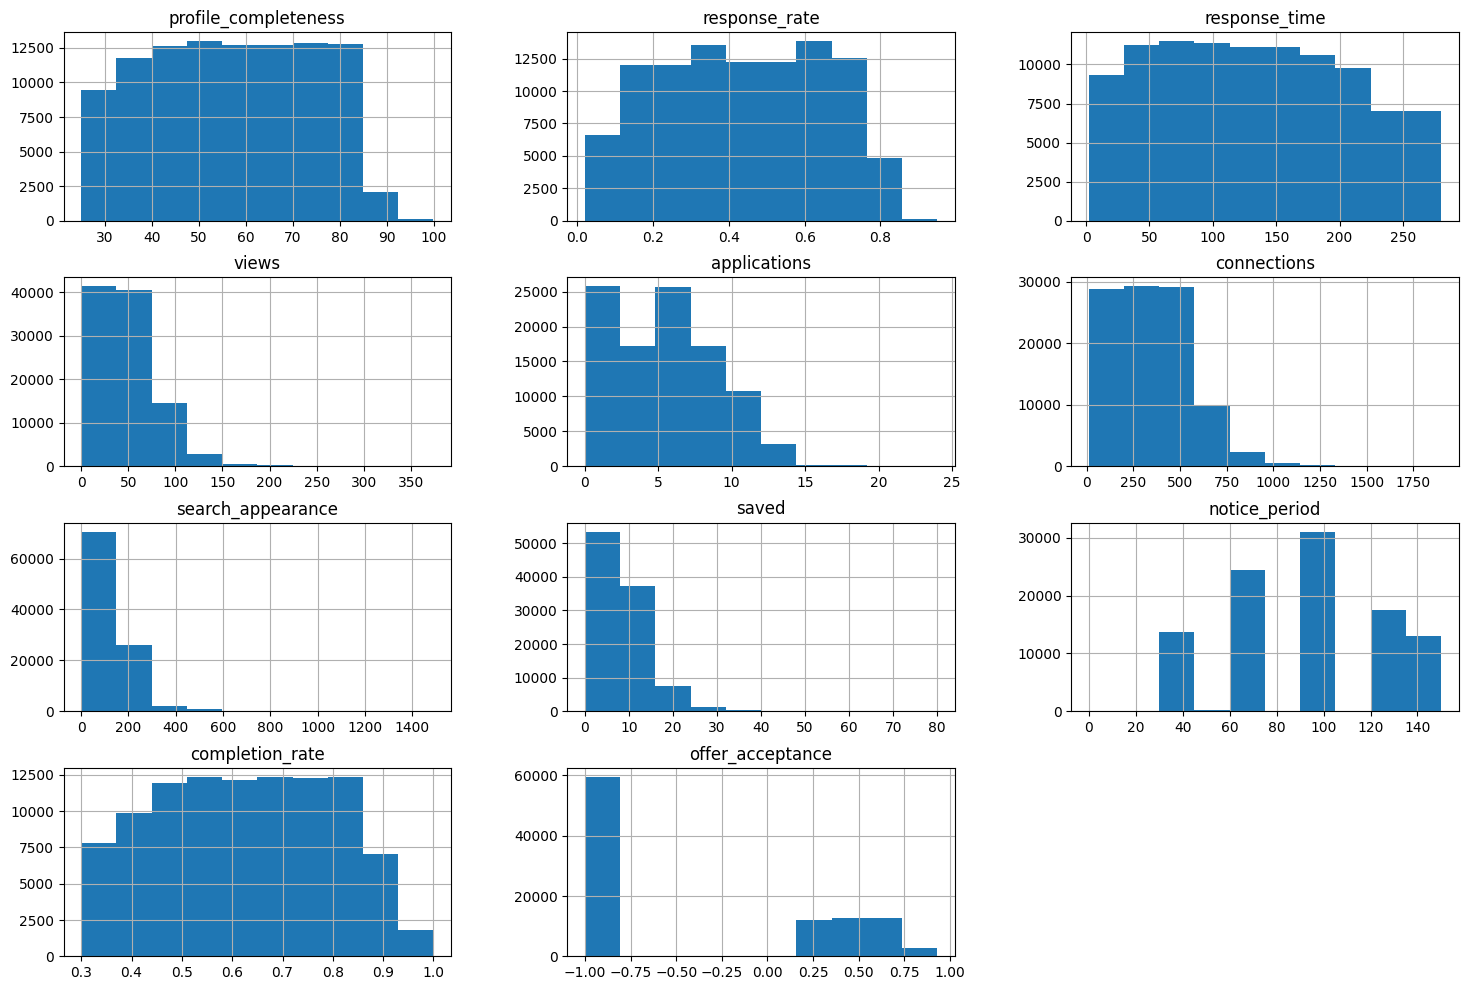

In [25]:
signals_df.hist(
    figsize=(18,12)
)

In [40]:
import pandas as pd
import numpy as np

availability_df = signals_df.copy()

In [36]:
availability_score = signals_df[["open_to_work","notice_period"]]

availability_score

,open_to_work,notice_period
0,True,60
1,True,60
2,False,150
3,False,120
4,True,30
...,...,...
99995,False,30
99996,True,30
99997,False,90
99998,True,120


In [42]:
availability_df["notice_score"] = (
    1 -
    (
        availability_df["notice_period"]
        /
        availability_df["notice_period"].max()
    )
)

availability_df

,candidate_id,profile_completeness,open_to_work,response_rate,response_time,views,applications,connections,search_appearance,saved,notice_period,completion_rate,offer_acceptance,notice_score
0,CAND_0000001,86.9,True,0.34,177.8,23,2,356,249,4,60,0.71,0.58,0.6
1,CAND_0000002,78.7,True,0.29,171.6,7,1,179,107,10,60,0.62,-1.00,0.6
2,CAND_0000003,31.9,False,0.46,119.4,1,9,19,28,4,150,0.86,-1.00,0.0
3,CAND_0000004,28.5,False,0.26,104.1,3,9,485,5,8,120,0.35,-1.00,0.2
4,CAND_0000005,84.6,True,0.37,116.7,12,2,300,67,1,30,0.74,-1.00,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CAND_0099996,41.4,False,0.45,259.8,52,5,325,98,7,30,0.87,-1.00,0.8
99996,CAND_0099997,42.7,True,0.41,108.6,42,4,292,49,0,30,0.38,-1.00,0.8
99997,CAND_0099998,75.9,False,0.33,139.0,84,0,442,187,26,90,0.79,0.74,0.4
99998,CAND_0099999,49.1,True,0.46,13.7,81,0,345,102,3,120,0.49,0.65,0.2


In [45]:
availability_df["availability_score"] = (

    0.6 *
    availability_df["open_to_work"]

    +

    0.4 *
    availability_df["notice_score"]

)

availability_df

,candidate_id,profile_completeness,open_to_work,response_rate,response_time,views,applications,connections,search_appearance,saved,notice_period,completion_rate,offer_acceptance,notice_score,availability_score
0,CAND_0000001,86.9,True,0.34,177.8,23,2,356,249,4,60,0.71,0.58,0.6,0.84
1,CAND_0000002,78.7,True,0.29,171.6,7,1,179,107,10,60,0.62,-1.00,0.6,0.84
2,CAND_0000003,31.9,False,0.46,119.4,1,9,19,28,4,150,0.86,-1.00,0.0,0.00
3,CAND_0000004,28.5,False,0.26,104.1,3,9,485,5,8,120,0.35,-1.00,0.2,0.08
4,CAND_0000005,84.6,True,0.37,116.7,12,2,300,67,1,30,0.74,-1.00,0.8,0.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CAND_0099996,41.4,False,0.45,259.8,52,5,325,98,7,30,0.87,-1.00,0.8,0.32
99996,CAND_0099997,42.7,True,0.41,108.6,42,4,292,49,0,30,0.38,-1.00,0.8,0.92
99997,CAND_0099998,75.9,False,0.33,139.0,84,0,442,187,26,90,0.79,0.74,0.4,0.16
99998,CAND_0099999,49.1,True,0.46,13.7,81,0,345,102,3,120,0.49,0.65,0.2,0.68


Component 2: Responsiveness Score


In [47]:
availability_df["response_time_score"] = (

    1 -

    (
        availability_df["response_time"]
        /
        availability_df["response_time"].max()
    )

)

availability_df["response_time_score"]

0        0.365000
1        0.387143
2        0.573571
3        0.628214
4        0.583214
           ...   
99995    0.072143
99996    0.612143
99997    0.503571
99998    0.951071
99999    0.028571
Name: response_time_score, Length: 100000, dtype: float64

In [49]:
availability_df["responsiveness_score"] = (

    0.7 *
    availability_df["response_rate"]

    +

    0.3 *
    availability_df["response_time_score"]

)

availability_df["responsiveness_score"]

0        0.347500
1        0.319143
2        0.494071
3        0.370464
4        0.433964
           ...   
99995    0.336643
99996    0.470643
99997    0.382071
99998    0.607321
99999    0.134571
Name: responsiveness_score, Length: 100000, dtype: float64

Component 3: Recruiter Demand Score

In [50]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

availability_df[
[
"views_norm",
"search_norm",
"saved_norm"
]
] = scaler.fit_transform(

availability_df[
[
"views",
"search_appearance",
"saved"
]
]

)

In [51]:
availability_df

,candidate_id,profile_completeness,open_to_work,response_rate,response_time,views,applications,connections,search_appearance,saved,notice_period,completion_rate,offer_acceptance,notice_score,availability_score,response_time_score,responsiveness_score,views_norm,search_norm,saved_norm
0,CAND_0000001,86.9,True,0.34,177.8,23,2,356,249,4,60,0.71,0.58,0.6,0.84,0.365000,0.347500,0.061497,0.167114,0.0500
1,CAND_0000002,78.7,True,0.29,171.6,7,1,179,107,10,60,0.62,-1.00,0.6,0.84,0.387143,0.319143,0.018717,0.071812,0.1250
2,CAND_0000003,31.9,False,0.46,119.4,1,9,19,28,4,150,0.86,-1.00,0.0,0.00,0.573571,0.494071,0.002674,0.018792,0.0500
3,CAND_0000004,28.5,False,0.26,104.1,3,9,485,5,8,120,0.35,-1.00,0.2,0.08,0.628214,0.370464,0.008021,0.003356,0.1000
4,CAND_0000005,84.6,True,0.37,116.7,12,2,300,67,1,30,0.74,-1.00,0.8,0.92,0.583214,0.433964,0.032086,0.044966,0.0125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CAND_0099996,41.4,False,0.45,259.8,52,5,325,98,7,30,0.87,-1.00,0.8,0.32,0.072143,0.336643,0.139037,0.065772,0.0875
99996,CAND_0099997,42.7,True,0.41,108.6,42,4,292,49,0,30,0.38,-1.00,0.8,0.92,0.612143,0.470643,0.112299,0.032886,0.0000
99997,CAND_0099998,75.9,False,0.33,139.0,84,0,442,187,26,90,0.79,0.74,0.4,0.16,0.503571,0.382071,0.224599,0.125503,0.3250
99998,CAND_0099999,49.1,True,0.46,13.7,81,0,345,102,3,120,0.49,0.65,0.2,0.68,0.951071,0.607321,0.216578,0.068456,0.0375


In [54]:
availability_df["demand_score"] = (

    0.5 *
    availability_df["saved_norm"]

    +

    0.3 *
    availability_df["views_norm"]

    +

    0.2 *
    availability_df["search_norm"]

)

availability_df

,candidate_id,profile_completeness,open_to_work,response_rate,response_time,views,applications,connections,search_appearance,saved,...,completion_rate,offer_acceptance,notice_score,availability_score,response_time_score,responsiveness_score,views_norm,search_norm,saved_norm,demand_score
0,CAND_0000001,86.9,True,0.34,177.8,23,2,356,249,4,...,0.71,0.58,0.6,0.84,0.365000,0.347500,0.061497,0.167114,0.0500,0.076872
1,CAND_0000002,78.7,True,0.29,171.6,7,1,179,107,10,...,0.62,-1.00,0.6,0.84,0.387143,0.319143,0.018717,0.071812,0.1250,0.082477
2,CAND_0000003,31.9,False,0.46,119.4,1,9,19,28,4,...,0.86,-1.00,0.0,0.00,0.573571,0.494071,0.002674,0.018792,0.0500,0.029561
3,CAND_0000004,28.5,False,0.26,104.1,3,9,485,5,8,...,0.35,-1.00,0.2,0.08,0.628214,0.370464,0.008021,0.003356,0.1000,0.053078
4,CAND_0000005,84.6,True,0.37,116.7,12,2,300,67,1,...,0.74,-1.00,0.8,0.92,0.583214,0.433964,0.032086,0.044966,0.0125,0.024869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CAND_0099996,41.4,False,0.45,259.8,52,5,325,98,7,...,0.87,-1.00,0.8,0.32,0.072143,0.336643,0.139037,0.065772,0.0875,0.098616
99996,CAND_0099997,42.7,True,0.41,108.6,42,4,292,49,0,...,0.38,-1.00,0.8,0.92,0.612143,0.470643,0.112299,0.032886,0.0000,0.040267
99997,CAND_0099998,75.9,False,0.33,139.0,84,0,442,187,26,...,0.79,0.74,0.4,0.16,0.503571,0.382071,0.224599,0.125503,0.3250,0.254980
99998,CAND_0099999,49.1,True,0.46,13.7,81,0,345,102,3,...,0.49,0.65,0.2,0.68,0.951071,0.607321,0.216578,0.068456,0.0375,0.097415


In [60]:
availability_df["offer_acceptance"].isnull().sum()

np.int64(0)

Component 4: Reliability Score

In [59]:
availability_df["offer_acceptance"] = (
    availability_df["offer_acceptance"]
    .replace(-1, np.nan)
)

availability_df["offer_acceptance"]

0        0.58
1        0.48
2        0.48
3        0.48
4        0.48
         ... 
99995    0.48
99996    0.48
99997    0.74
99998    0.65
99999    0.48
Name: offer_acceptance, Length: 100000, dtype: float64

In [61]:
availability_df

,candidate_id,profile_completeness,open_to_work,response_rate,response_time,views,applications,connections,search_appearance,saved,...,completion_rate,offer_acceptance,notice_score,availability_score,response_time_score,responsiveness_score,views_norm,search_norm,saved_norm,demand_score
0,CAND_0000001,86.9,True,0.34,177.8,23,2,356,249,4,...,0.71,0.58,0.6,0.84,0.365000,0.347500,0.061497,0.167114,0.0500,0.076872
1,CAND_0000002,78.7,True,0.29,171.6,7,1,179,107,10,...,0.62,0.48,0.6,0.84,0.387143,0.319143,0.018717,0.071812,0.1250,0.082477
2,CAND_0000003,31.9,False,0.46,119.4,1,9,19,28,4,...,0.86,0.48,0.0,0.00,0.573571,0.494071,0.002674,0.018792,0.0500,0.029561
3,CAND_0000004,28.5,False,0.26,104.1,3,9,485,5,8,...,0.35,0.48,0.2,0.08,0.628214,0.370464,0.008021,0.003356,0.1000,0.053078
4,CAND_0000005,84.6,True,0.37,116.7,12,2,300,67,1,...,0.74,0.48,0.8,0.92,0.583214,0.433964,0.032086,0.044966,0.0125,0.024869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CAND_0099996,41.4,False,0.45,259.8,52,5,325,98,7,...,0.87,0.48,0.8,0.32,0.072143,0.336643,0.139037,0.065772,0.0875,0.098616
99996,CAND_0099997,42.7,True,0.41,108.6,42,4,292,49,0,...,0.38,0.48,0.8,0.92,0.612143,0.470643,0.112299,0.032886,0.0000,0.040267
99997,CAND_0099998,75.9,False,0.33,139.0,84,0,442,187,26,...,0.79,0.74,0.4,0.16,0.503571,0.382071,0.224599,0.125503,0.3250,0.254980
99998,CAND_0099999,49.1,True,0.46,13.7,81,0,345,102,3,...,0.49,0.65,0.2,0.68,0.951071,0.607321,0.216578,0.068456,0.0375,0.097415


In [63]:
availability_df["reliability_score"] = (

    0.6 *
    availability_df["completion_rate"]

    +

    0.4 *
    availability_df["offer_acceptance"]

)

availability_df

,candidate_id,profile_completeness,open_to_work,response_rate,response_time,views,applications,connections,search_appearance,saved,...,offer_acceptance,notice_score,availability_score,response_time_score,responsiveness_score,views_norm,search_norm,saved_norm,demand_score,reliability_score
0,CAND_0000001,86.9,True,0.34,177.8,23,2,356,249,4,...,0.58,0.6,0.84,0.365000,0.347500,0.061497,0.167114,0.0500,0.076872,0.658
1,CAND_0000002,78.7,True,0.29,171.6,7,1,179,107,10,...,0.48,0.6,0.84,0.387143,0.319143,0.018717,0.071812,0.1250,0.082477,0.564
2,CAND_0000003,31.9,False,0.46,119.4,1,9,19,28,4,...,0.48,0.0,0.00,0.573571,0.494071,0.002674,0.018792,0.0500,0.029561,0.708
3,CAND_0000004,28.5,False,0.26,104.1,3,9,485,5,8,...,0.48,0.2,0.08,0.628214,0.370464,0.008021,0.003356,0.1000,0.053078,0.402
4,CAND_0000005,84.6,True,0.37,116.7,12,2,300,67,1,...,0.48,0.8,0.92,0.583214,0.433964,0.032086,0.044966,0.0125,0.024869,0.636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CAND_0099996,41.4,False,0.45,259.8,52,5,325,98,7,...,0.48,0.8,0.32,0.072143,0.336643,0.139037,0.065772,0.0875,0.098616,0.714
99996,CAND_0099997,42.7,True,0.41,108.6,42,4,292,49,0,...,0.48,0.8,0.92,0.612143,0.470643,0.112299,0.032886,0.0000,0.040267,0.420
99997,CAND_0099998,75.9,False,0.33,139.0,84,0,442,187,26,...,0.74,0.4,0.16,0.503571,0.382071,0.224599,0.125503,0.3250,0.254980,0.770
99998,CAND_0099999,49.1,True,0.46,13.7,81,0,345,102,3,...,0.65,0.2,0.68,0.951071,0.607321,0.216578,0.068456,0.0375,0.097415,0.554


In [65]:
availability_df["behavior_score"] = (

    0.30 *
    availability_df["availability_score"]

    +

    0.25 *
    availability_df["responsiveness_score"]

    +

    0.25 *
    availability_df["demand_score"]

    +

    0.20 *
    availability_df["reliability_score"]

)

availability_df["behavior_score"]

0        0.489693
1        0.465205
2        0.272508
3        0.210285
4        0.517908
           ...   
99995    0.347615
99996    0.487727
99997    0.361263
99998    0.490984
99999    0.183813
Name: behavior_score, Length: 100000, dtype: float64

In [68]:
availability_df[
[
"candidate_id",
"availability_score",
"responsiveness_score",
"demand_score",
"reliability_score",
"behavior_score"
]
].sort_values(
    "behavior_score",
    ascending=False
).head(20)

,candidate_id,availability_score,responsiveness_score,demand_score,reliability_score,behavior_score
37979,CAND_0037980,1.00,0.695571,0.706385,0.866,0.823689
6566,CAND_0006567,0.84,0.825679,0.749763,0.874,0.820660
95618,CAND_0095619,0.92,0.920786,0.555795,0.814,0.807945
61256,CAND_0061257,0.92,0.855750,0.700043,0.672,0.799348
39753,CAND_0039754,0.92,0.825750,0.615164,0.808,0.797829
40886,CAND_0040887,0.96,0.822964,0.517501,0.832,0.789516
58782,CAND_0058783,0.92,0.933607,0.512454,0.746,0.786715
64325,CAND_0064326,0.88,0.943536,0.545279,0.732,0.782604
93911,CAND_0093912,0.92,0.719464,0.687983,0.768,0.781462
52681,CAND_0052682,0.92,0.879357,0.446714,0.868,0.781118


In [69]:
availability_df["behavior_score"].describe()

count    100000.000000
mean          0.367655
std           0.108797
min           0.102943
25%           0.283261
50%           0.346880
75%           0.454381
max           0.823689
Name: behavior_score, dtype: float64

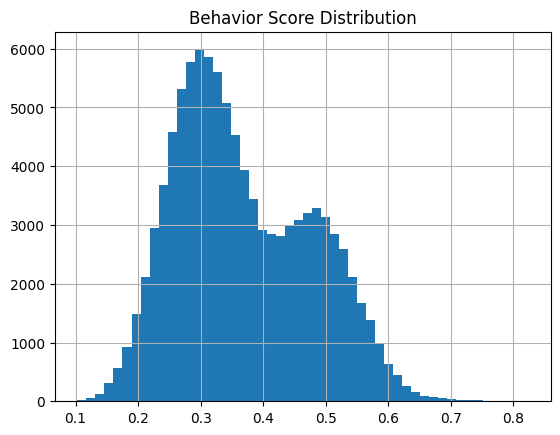

In [70]:
import matplotlib.pyplot as plt

availability_df["behavior_score"].hist(
    bins=50
)

plt.title(
    "Behavior Score Distribution"
)

plt.show()

In [74]:
availability_df.to_csv("candidate_behavior_scores_full.csv", index=False)

Phase 3.3 — Trust & Consistency Forensics

In [91]:
experience_rows = []

for c in candidates:

    claimed_years = (
        c["profile"]["years_of_experience"]
    )

    claimed_months = (
        claimed_years * 12
    )

    actual_months = sum(
        job["duration_months"]
        for job in c["career_history"]
    )

    difference = abs(
        claimed_months - actual_months
    )

    experience_score = max(
        0,
        1 - (
            difference /
            max(claimed_months, 1)
        )
    )

    experience_rows.append({
        "candidate_id": c["candidate_id"],
        "claimed_months": claimed_months,
        "actual_months": actual_months,
        "difference": difference,
        "experience_score": experience_score
    })

In [108]:
experience_df = pd.DataFrame(experience_rows)

experience_df

,candidate_id,claimed_months,actual_months,difference,experience_score
0,CAND_0000001,82.8,82,0.8,0.990338
1,CAND_0000002,150.0,149,1.0,0.993333
2,CAND_0000003,13.2,13,0.2,0.984848
3,CAND_0000004,45.6,44,1.6,0.964912
4,CAND_0000005,132.0,130,2.0,0.984848
...,...,...,...,...,...
99995,CAND_0099996,160.8,159,1.8,0.988806
99996,CAND_0099997,127.2,125,2.2,0.982704
99997,CAND_0099998,87.6,86,1.6,0.981735
99998,CAND_0099999,51.6,50,1.6,0.968992


In [110]:
experience_df.sort_values(
    "experience_score",
    ascending=False
)

,candidate_id,claimed_months,actual_months,difference,experience_score
99975,CAND_0099976,18.0,18,0.0,1.0
99965,CAND_0099966,30.0,30,0.0,1.0
34214,CAND_0034215,60.0,60,0.0,1.0
99938,CAND_0099939,84.0,84,0.0,1.0
82803,CAND_0082804,30.0,30,0.0,1.0
...,...,...,...,...,...
36999,CAND_0037000,32.4,75,42.6,0.0
19479,CAND_0019480,33.6,87,53.4,0.0
10293,CAND_0010294,96.0,220,124.0,0.0
55684,CAND_0055685,16.8,64,47.2,0.0


In [115]:
trust_based_candidates = experience_df[experience_df["experience_score"] <= 0.1]

print(f"Total candidates with experience score <= 0.1: {len(trust_based_candidates)}")
print(f"Sample: {trust_based_candidates}")

Total candidates with experience score <= 0.1: 33
Sample:        candidate_id  claimed_months  actual_months  difference  \
3429   CAND_0003430           164.4             11       153.4   
5290   CAND_0005291           153.6             11       142.6   
7352   CAND_0007353           118.8            251       132.2   
8959   CAND_0008960           123.6            271       147.4   
10293  CAND_0010294            96.0            220       124.0   
18514  CAND_0018515           102.0            211       109.0   
19479  CAND_0019480            33.6             87        53.4   
24751  CAND_0024752           178.8              8       170.8   
25578  CAND_0025579           154.8             12       142.8   
35103  CAND_0035104            66.0            162        96.0   
36298  CAND_0036299           146.4              8       138.4   
36999  CAND_0037000            32.4             75        42.6   
37538  CAND_0037539            58.8            115        56.2   
38430  CAND_003843

In [116]:
experience_df["difference"].describe()

count    100000.000000
mean          1.279914
std           2.680588
min           0.000000
25%           0.600000
50%           1.200000
75%           1.800000
max         185.000000
Name: difference, dtype: float64

In [94]:
experience_df.sort_values(
    "difference",
    ascending=False
).head(100)

,candidate_id,claimed_months,actual_months,difference,experience_score
40074,CAND_0040075,180.0,365,185.0,0.000000
24751,CAND_0024752,178.8,8,170.8,0.044743
96149,CAND_0096150,176.4,10,166.4,0.056689
38430,CAND_0038431,180.0,16,164.0,0.088889
3429,CAND_0003430,164.4,11,153.4,0.066910
...,...,...,...,...,...
88847,CAND_0088848,170.4,166,4.4,0.974178
69337,CAND_0069338,170.4,166,4.4,0.974178
59822,CAND_0059823,164.4,160,4.4,0.973236
15655,CAND_0015656,128.4,124,4.4,0.965732


In [106]:
low_experience_score = experience_df[experience_df["experience_score"] > 0.1]
print(low_experience_score)

       candidate_id  claimed_months  actual_months  difference  \
0      CAND_0000001            82.8             82         0.8   
1      CAND_0000002           150.0            149         1.0   
2      CAND_0000003            13.2             13         0.2   
3      CAND_0000004            45.6             44         1.6   
4      CAND_0000005           132.0            130         2.0   
...             ...             ...            ...         ...   
99995  CAND_0099996           160.8            159         1.8   
99996  CAND_0099997           127.2            125         2.2   
99997  CAND_0099998            87.6             86         1.6   
99998  CAND_0099999            51.6             50         1.6   
99999  CAND_0100000           148.8            147         1.8   

       experience_score  
0              0.990338  
1              0.993333  
2              0.984848  
3              0.964912  
4              0.984848  
...                 ...  
99995          0.988806  

In [119]:
date_rows = []

for c in candidates:

    s = c["redrob_signals"]

    signup = pd.to_datetime(
        s["signup_date"]
    )

    last_active = pd.to_datetime(
        s["last_active_date"]
    )

    anomaly = signup > last_active

    date_rows.append({

        "candidate_id":
        c["candidate_id"],

        "date_anomaly":
        anomaly,

        "date_score":
        0 if anomaly else 1

    })

In [120]:
date_df = pd.DataFrame(
    date_rows
)

In [121]:
date_df["date_anomaly"].sum()

np.int64(7496)

In [132]:
education_rows = []

for c in candidates:
    
    for edu in c["education"]:
        education_end_year = edu["end_year"]
    
    education_rows.append({
        "candidate_id": c["candidate_id"],
        "education_end_year": education_end_year
    })

education_df = pd.DataFrame(education_rows)
education_df.head()

,candidate_id,education_end_year
0,CAND_0000001,2020
1,CAND_0000002,2011
2,CAND_0000003,2021
3,CAND_0000004,2016
4,CAND_0000005,2012


In [139]:


for c in candidates:
    # Get the first (most recent) degree, or empty string if no education
    degree_done = c["education"][0]["field_of_study"] if c["education"] else ""
    education_rows.append(degree_done)

education_df

,candidate_id,education_end_year,degree
0,CAND_0000001,2020,Computer Science
1,CAND_0000002,2011,Mathematics
2,CAND_0000003,2021,Chemical Engineering
3,CAND_0000004,2016,Machine Learning
4,CAND_0000005,2012,Information Technology
...,...,...,...
99995,CAND_0099996,2007,Mechanical Engineering
99996,CAND_0099997,2019,MBA
99997,CAND_0099998,2011,Artificial Intelligence
99998,CAND_0099999,2011,Commerce
